In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

In [6]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cuda


In [8]:
class CNNBinary(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(32, 1),)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

In [ ]:
LABEL_TO_INT = {"Non-Cracked": 0, "Cracked": 1}
INT_TO_LABEL = {0: "Non-Cracked", 1: "Cracked"}

def get_phase2_test_split(df: pd.DataFrame) -> pd.DataFrame:
    _, test_df = train_test_split(df, test_size=0.2, random_state=42,stratify=df["Label"],)
    return test_df.reset_index(drop=True)

def row_to_tensor(image_data) -> torch.Tensor:
    image = np.asarray(image_data, dtype=np.float32) / 255.0
    if image.ndim == 2:
        image = np.expand_dims(image, axis=0) 
    elif image.ndim == 3:
        image = np.transpose(image, (2, 0, 1)) 
    else:
        raise ValueError(f"Unsupported image shape: {image.shape}")
    return torch.from_numpy(image)

def load_trained_model(weights_path: Path) -> nn.Module:
    model = CNNBinary().to(device)
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def find_false_negatives(model: nn.Module, df: pd.DataFrame, dataset_name: str, threshold: float = 0.5, batch_size: int = 64,) -> pd.DataFrame:
    filenames = df["FileName"].tolist()
    true_labels = df["Label"].map(LABEL_TO_INT).astype(int).to_numpy()
    tensors = [row_to_tensor(img) for img in df["ImageData"].tolist()]
    probs = []
    with torch.no_grad():
        for start in range(0, len(tensors), batch_size):
            batch = torch.stack(tensors[start : start + batch_size]).to(device)
            logits = model(batch).squeeze(1)
            batch_probs = torch.sigmoid(logits).cpu().numpy()
            probs.extend(batch_probs.tolist())
    probs = np.array(probs)
    probs_noncracked = 1.0 - probs
    preds = (probs >= threshold).astype(int)
    out = pd.DataFrame({"Dataset": dataset_name,
                        "FileName": filenames,
                        "TrueLabel": [INT_TO_LABEL[v] for v in true_labels],
                        "PredictedLabel": [INT_TO_LABEL[v] for v in preds],
                        "ProbNonCracked": probs_noncracked})
    false_negatives = out[(out["TrueLabel"] == "Cracked") & (out["PredictedLabel"] == "Non-Cracked")].copy()
    false_negatives = false_negatives.sort_values("ProbNonCracked", ascending=False).reset_index(drop=True)
    return false_negatives

In [47]:
# Load data
root = Path.cwd()
wall_df = pd.read_hdf(root / "wall_data.h5", key="walls")
deck_df = pd.read_hdf(root / "deck_data.h5", key="decks")

wall_test = get_phase2_test_split(wall_df)
deck_test = get_phase2_test_split(deck_df)

model_walls = load_trained_model(root / "model_walls.pth")
model_decks = load_trained_model(root / "model_decks.pth")

In [48]:
# Use 0.5 threshold
false_neg_walls = find_false_negatives(model_walls, wall_test, dataset_name="Walls", threshold=0.5)
false_neg_decks = find_false_negatives(model_decks, deck_test, dataset_name="Decks", threshold=0.5)

print(f"Walls false negatives (Cracked -> predicted Non-Cracked): {len(false_neg_walls)}")
print(f"Decks false negatives (Cracked -> predicted Non-Cracked): {len(false_neg_decks)}")

if len(false_neg_walls) == 0 and len(false_neg_decks) == 0:
    print("No false negatives found at threshold=0.5.")
else:
    display(false_neg_walls)
    display(false_neg_decks)

Walls false negatives (Cracked -> predicted Non-Cracked): 195
Decks false negatives (Cracked -> predicted Non-Cracked): 158


,Dataset,FileName,TrueLabel,PredictedLabel,ProbNonCracked
0,Walls,7111-14.jpg,Cracked,Non-Cracked,0.999249
1,Walls,7117-108.jpg,Cracked,Non-Cracked,0.997682
2,Walls,7111-221.jpg,Cracked,Non-Cracked,0.997640
3,Walls,7111-123.jpg,Cracked,Non-Cracked,0.997190
4,Walls,7125-171.jpg,Cracked,Non-Cracked,0.996835
...,...,...,...,...,...
190,Walls,7078-67.jpg,Cracked,Non-Cracked,0.532046
191,Walls,7092-146.jpg,Cracked,Non-Cracked,0.526849
192,Walls,7085-148.jpg,Cracked,Non-Cracked,0.518053
193,Walls,7074-86.jpg,Cracked,Non-Cracked,0.507453


,Dataset,FileName,TrueLabel,PredictedLabel,ProbNonCracked
0,Decks,7048-71.jpg,Cracked,Non-Cracked,0.982688
1,Decks,7006-227.jpg,Cracked,Non-Cracked,0.979720
2,Decks,7048-72.jpg,Cracked,Non-Cracked,0.977765
3,Decks,7021-226.jpg,Cracked,Non-Cracked,0.969898
4,Decks,7039-136.jpg,Cracked,Non-Cracked,0.969279
...,...,...,...,...,...
153,Decks,7028-137.jpg,Cracked,Non-Cracked,0.602042
154,Decks,7020-73.jpg,Cracked,Non-Cracked,0.594932
155,Decks,7049-218.jpg,Cracked,Non-Cracked,0.571696
156,Decks,7040-238.jpg,Cracked,Non-Cracked,0.568024


In [27]:
top_n = 30
top10_walls_noncracked = false_neg_walls.head(top_n)
top10_decks_noncracked = false_neg_decks.head(top_n)

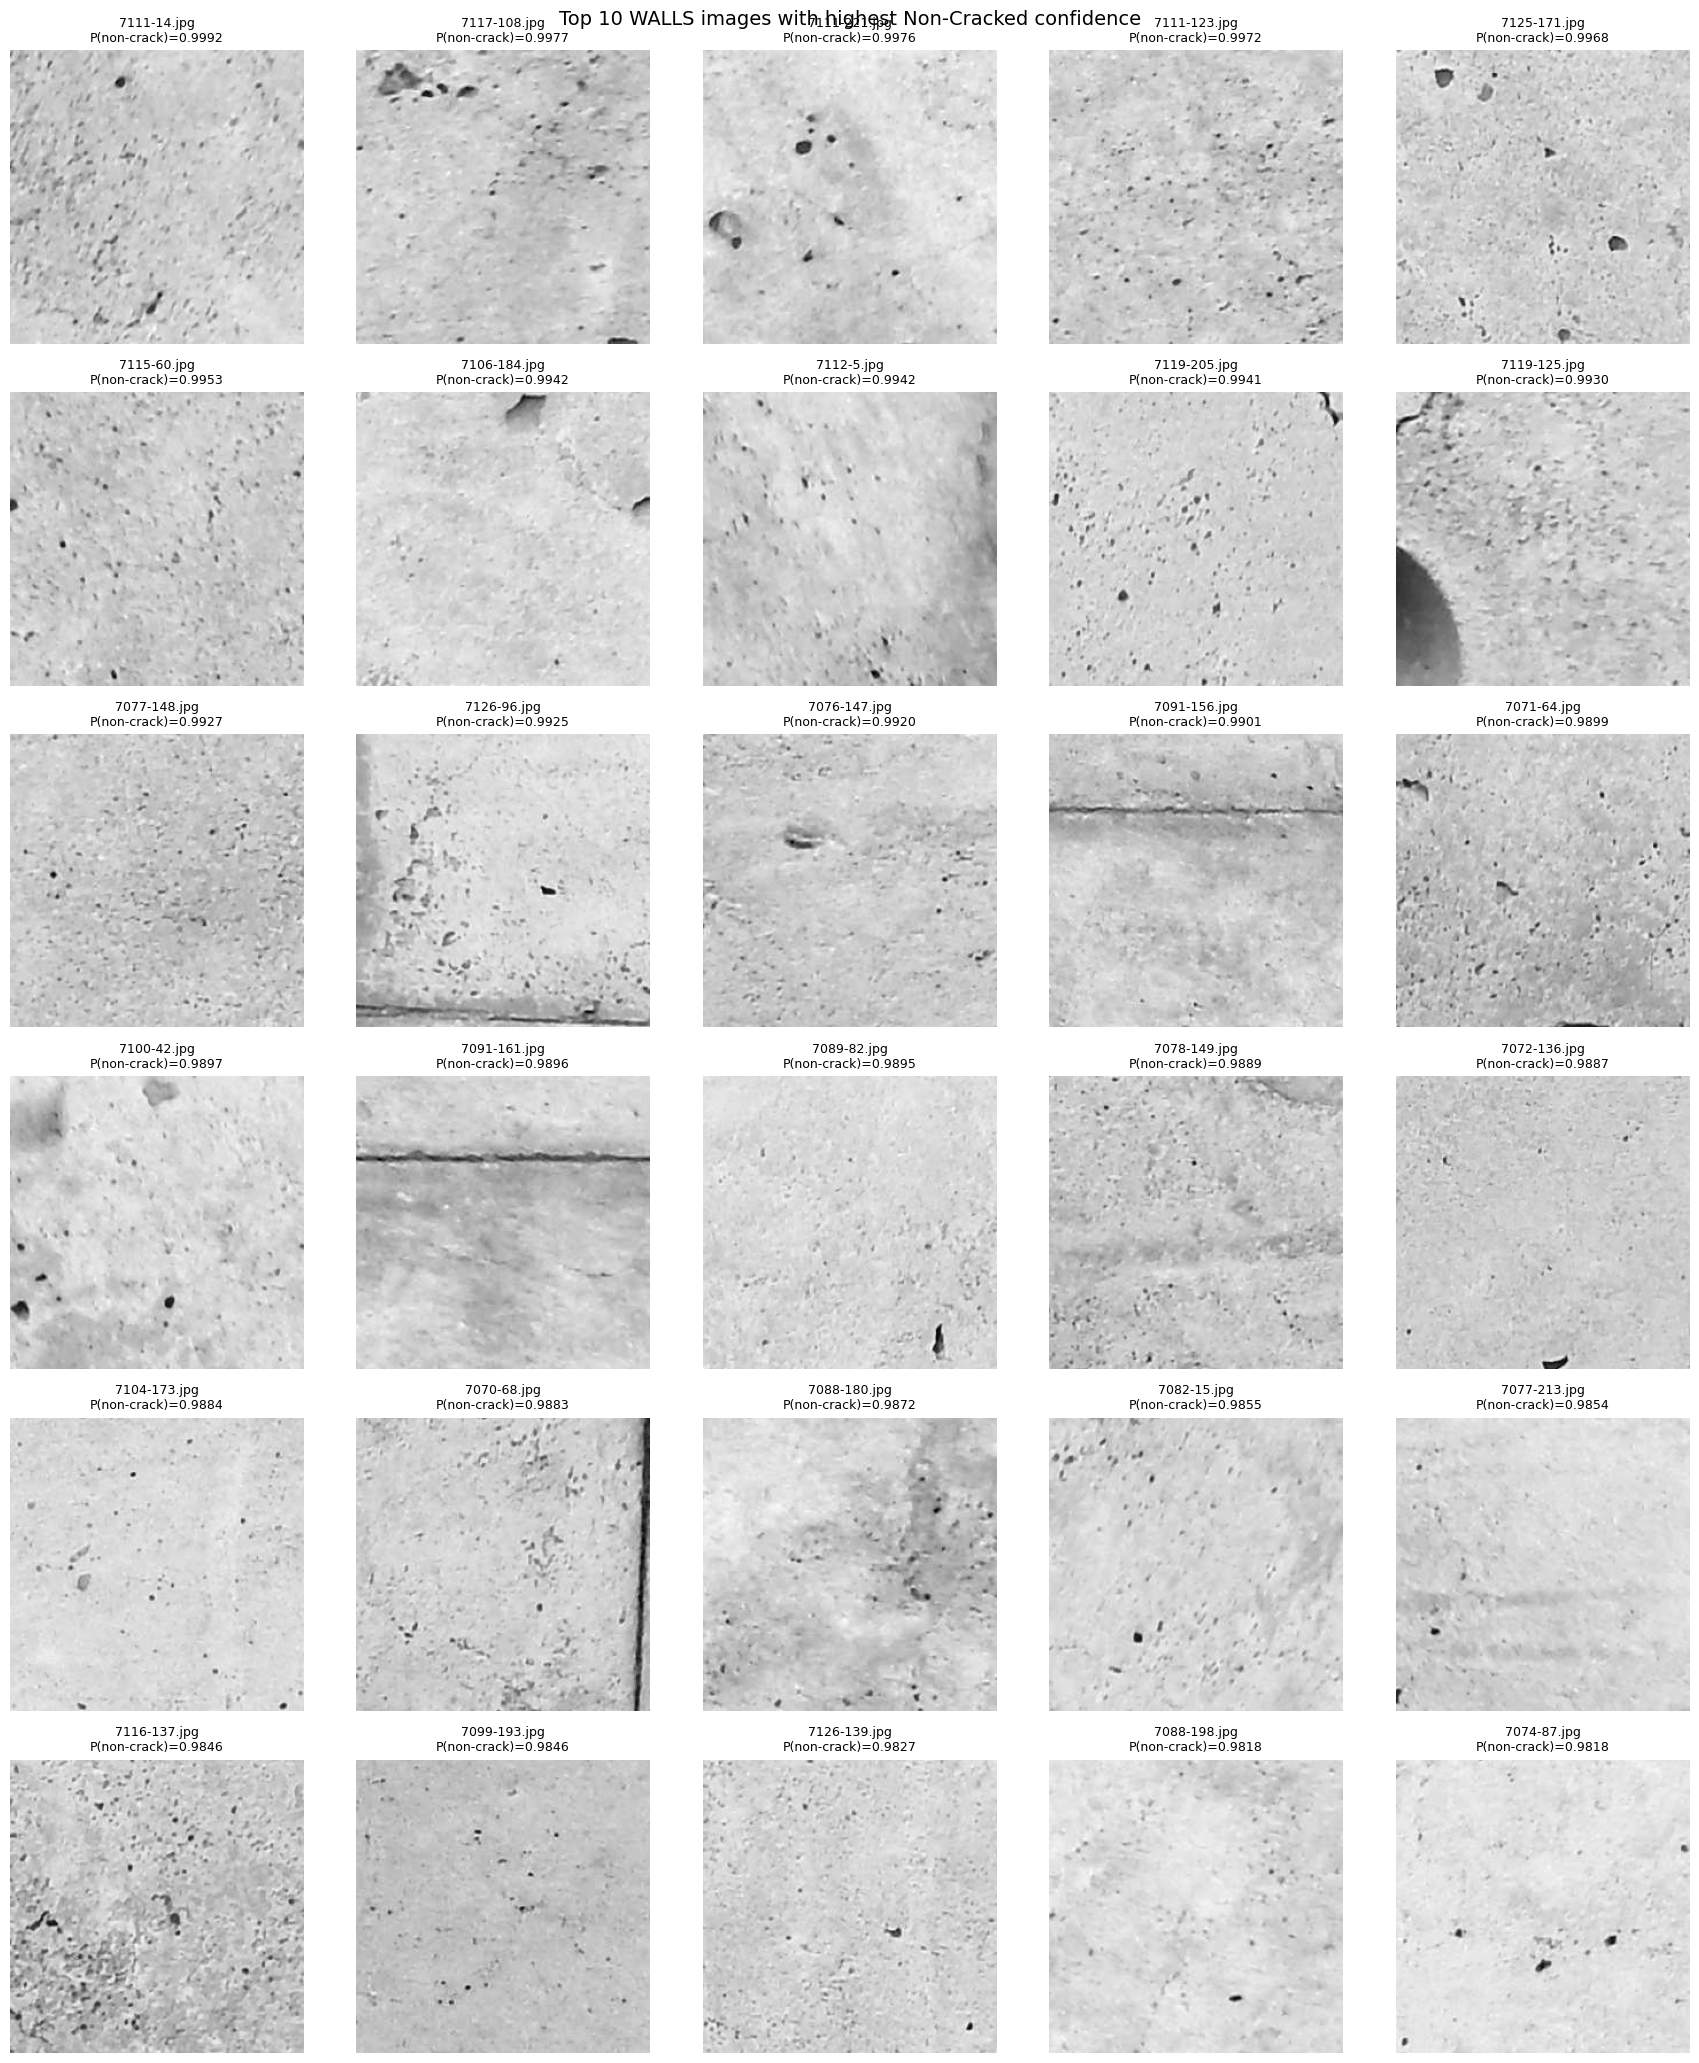

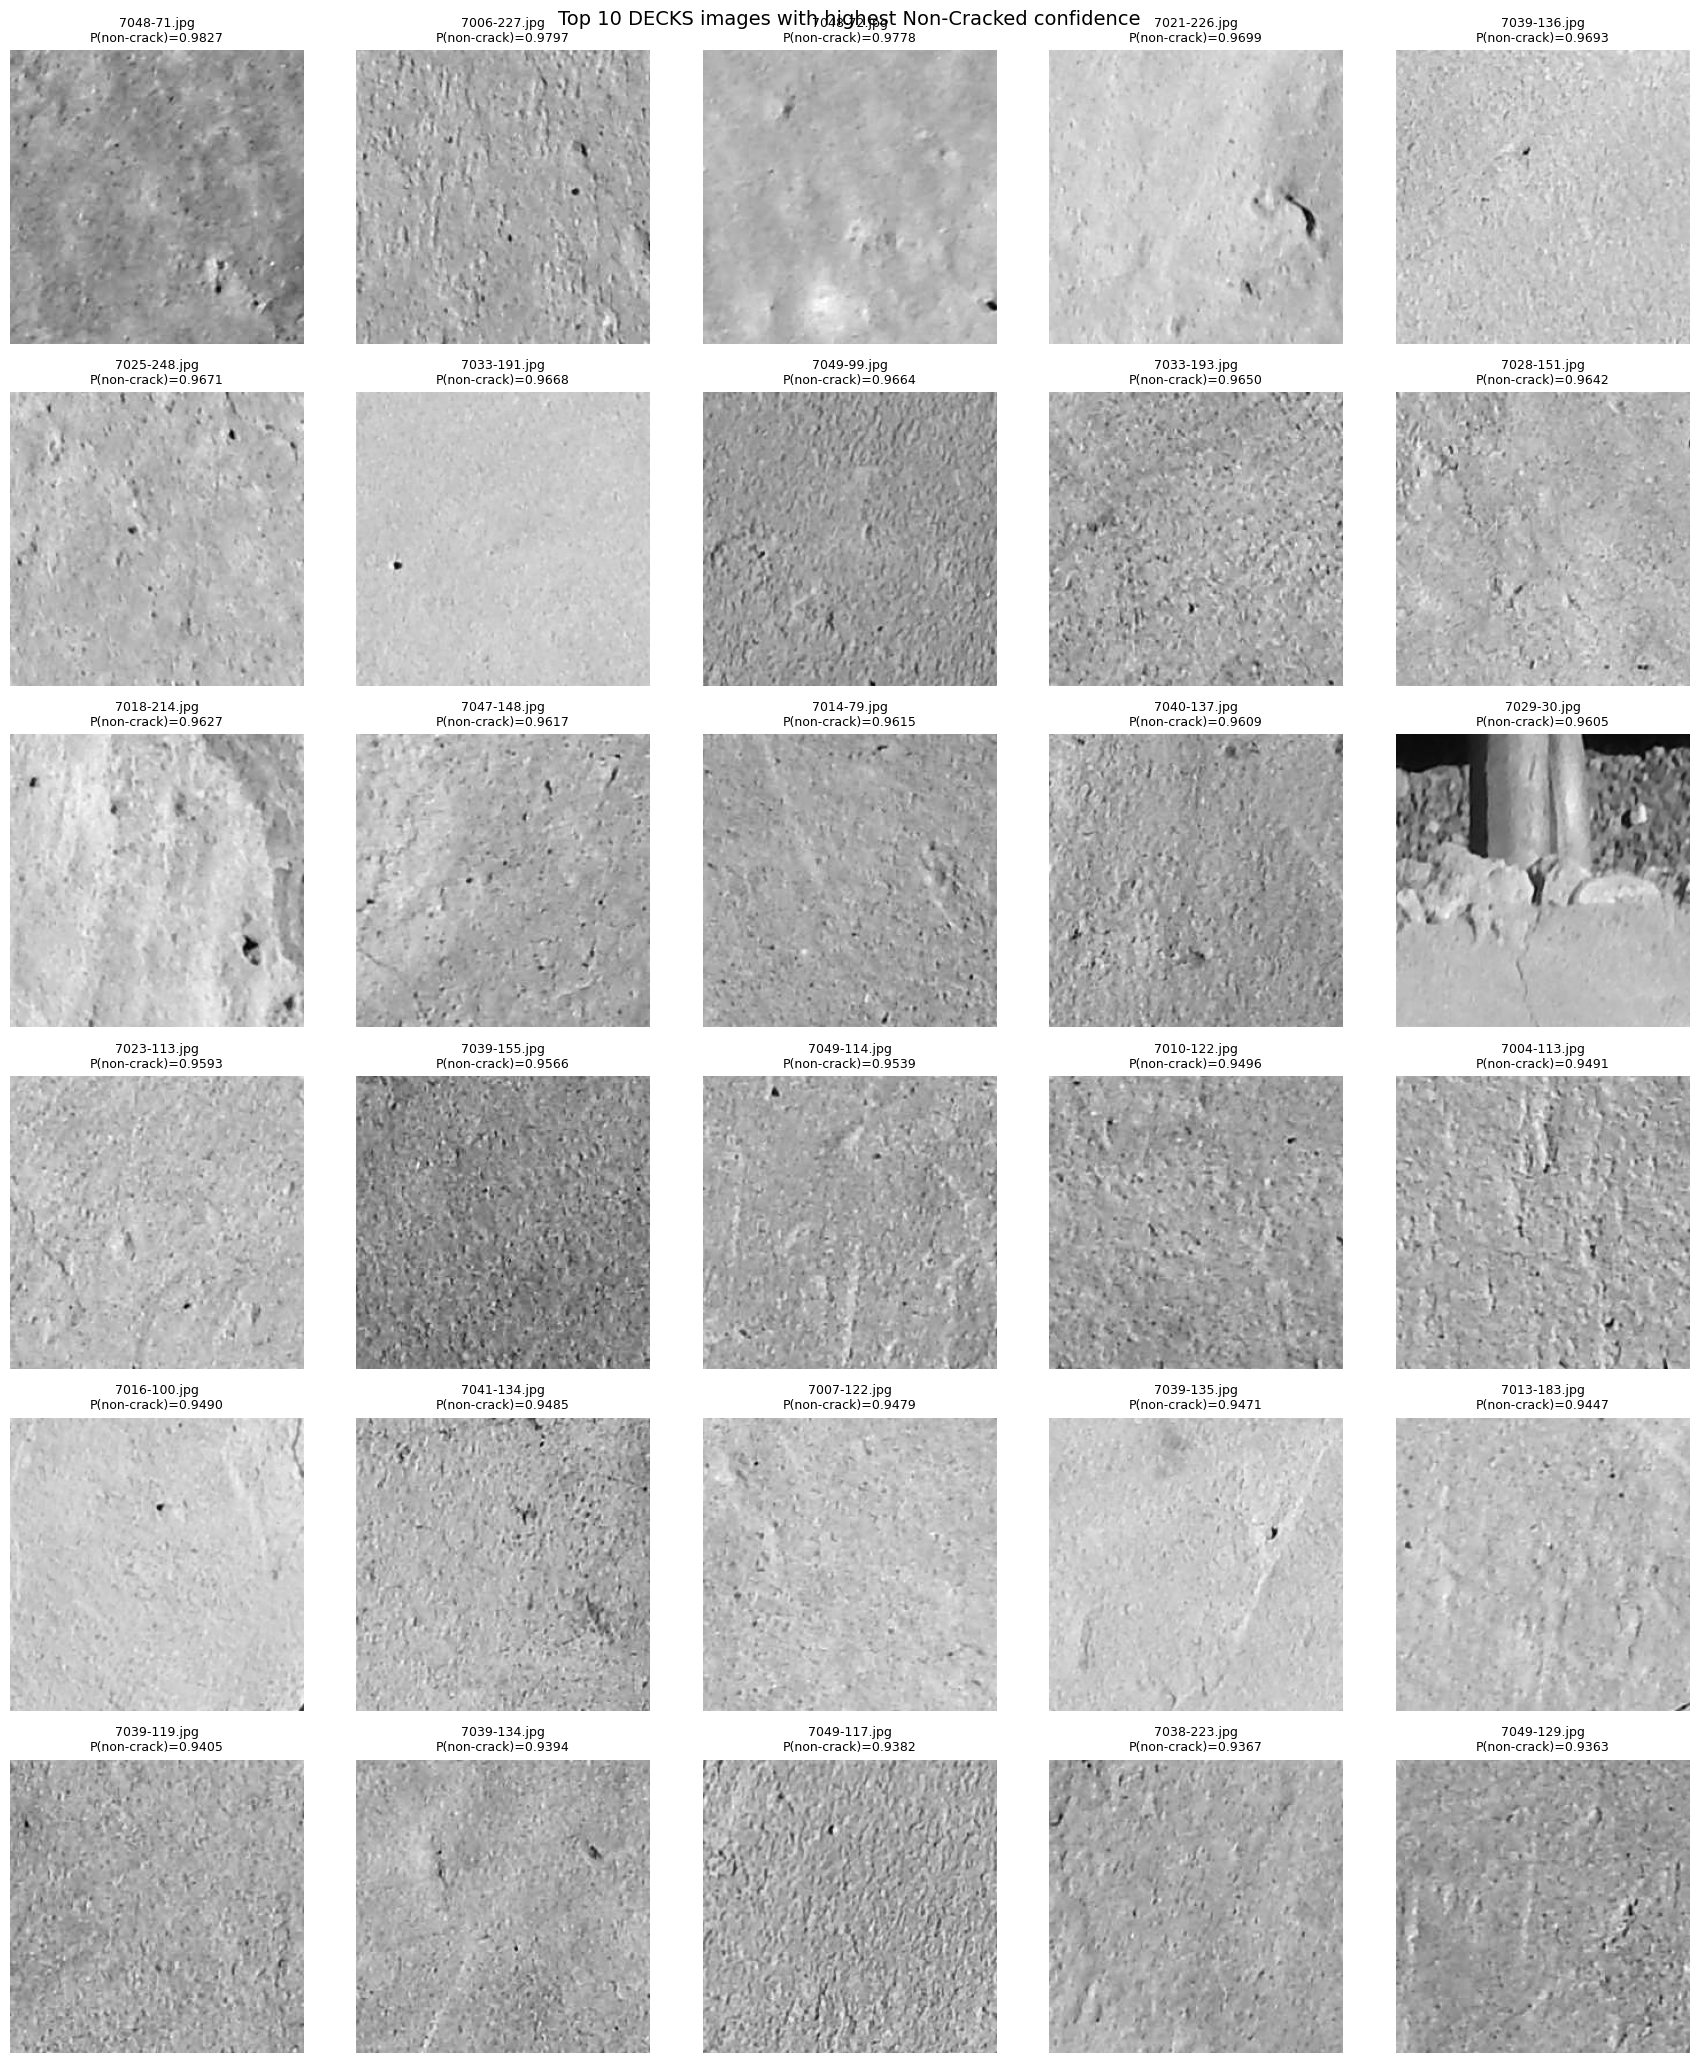

In [43]:
import matplotlib.pyplot as plt

def show_top_images(df_test: pd.DataFrame, top_df: pd.DataFrame, title: str, ncols: int = 5):
    n = len(top_df)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, row in top_df.reset_index(drop=True).iterrows():
        ax = axes[i]
        file_name = row["FileName"]

        matched = df_test[df_test["FileName"] == file_name]
        if matched.empty:
            ax.axis("off")
            ax.set_title(f"Missing: {file_name}", fontsize=9)
            continue

        img = np.asarray(matched.iloc[0]["ImageData"])
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)

        ax.set_title(f"{file_name}\nP(non-crack)={row['ProbNonCracked']:.4f}", fontsize=9)
        ax.axis("off")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

show_top_images(wall_test, top10_walls_noncracked, "Top 10 WALLS images with highest Non-Cracked confidence")
show_top_images(deck_test, top10_decks_noncracked, "Top 10 DECKS images with highest Non-Cracked confidence")

In [49]:
false_neg_all_walls = find_false_negatives(model_walls, wall_df, dataset_name="Walls", threshold=0.5)
false_neg_all_decks = find_false_negatives(model_decks, deck_df, dataset_name="Decks", threshold=0.5)

In [51]:
# Find those with 95% confidence of being Non-Cracked
confidence = 0.90
wall_list = false_neg_all_walls[false_neg_all_walls['ProbNonCracked'] > confidence]['FileName'].tolist()
deck_list = false_neg_all_decks[false_neg_all_decks['ProbNonCracked'] > confidence]['FileName'].tolist()
print(f"Walls false negatives (Cracked -> predicted Non-Cracked): {len(false_neg_all_walls[false_neg_all_walls['ProbNonCracked'] > confidence])}")
print(f"Decks false negatives (Cracked -> predicted Non-Cracked): {len(false_neg_all_decks[false_neg_all_decks['ProbNonCracked'] > confidence])}")
display(false_neg_all_walls[false_neg_all_walls['ProbNonCracked'] > confidence])
display(false_neg_all_decks[false_neg_all_decks['ProbNonCracked'] > confidence])

Walls false negatives (Cracked -> predicted Non-Cracked): 421
Decks false negatives (Cracked -> predicted Non-Cracked): 213


,Dataset,FileName,TrueLabel,PredictedLabel,ProbNonCracked
0,Walls,7117-35.jpg,Cracked,Non-Cracked,0.999459
1,Walls,7111-14.jpg,Cracked,Non-Cracked,0.999249
2,Walls,7101-123.jpg,Cracked,Non-Cracked,0.999110
3,Walls,7116-40.jpg,Cracked,Non-Cracked,0.998617
4,Walls,7116-57.jpg,Cracked,Non-Cracked,0.998488
...,...,...,...,...,...
416,Walls,7123-156.jpg,Cracked,Non-Cracked,0.902360
417,Walls,7135-152.jpg,Cracked,Non-Cracked,0.901578
418,Walls,7118-27.jpg,Cracked,Non-Cracked,0.900817
419,Walls,7087-194.jpg,Cracked,Non-Cracked,0.900717


,Dataset,FileName,TrueLabel,PredictedLabel,ProbNonCracked
0,Decks,7024-163.jpg,Cracked,Non-Cracked,0.998876
1,Decks,7016-29.jpg,Cracked,Non-Cracked,0.996269
2,Decks,7048-70.jpg,Cracked,Non-Cracked,0.990454
3,Decks,7026-215.jpg,Cracked,Non-Cracked,0.989267
4,Decks,7048-229.jpg,Cracked,Non-Cracked,0.987459
...,...,...,...,...,...
208,Decks,7048-142.jpg,Cracked,Non-Cracked,0.900841
209,Decks,7034-12.jpg,Cracked,Non-Cracked,0.900540
210,Decks,7048-20.jpg,Cracked,Non-Cracked,0.900487
211,Decks,7020-109.jpg,Cracked,Non-Cracked,0.900432


In [54]:
wall_cleaned = wall_df[~wall_df['FileName'].isin(wall_list)]
print(f"Original wall dataset size: {len(wall_df)}, Cleaned wall dataset size: {len(wall_cleaned)}")
deck_cleaned = deck_df[~deck_df['FileName'].isin(deck_list)]
print(f"Original deck dataset size: {len(deck_df)}, Cleaned deck dataset size: {len(deck_cleaned)}")

wall_cleaned.to_hdf(root / "wall_data_cleaned.h5", key="walls", mode="w")
deck_cleaned.to_hdf(root / "deck_data_cleaned.h5", key="decks", mode="w")

Original wall dataset size: 17939, Cleaned wall dataset size: 17518
Original deck dataset size: 13422, Cleaned deck dataset size: 13209


C:\Users\MSI-NB\AppData\Local\Temp\ipykernel_31128\3876569536.py:6: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['ImageData'], dtype='str')]

  wall_cleaned.to_hdf(root / "wall_data_cleaned.h5", key="walls", mode="w")
C:\Users\MSI-NB\AppData\Local\Temp\ipykernel_31128\3876569536.py:7: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block2_values] [items->Index(['ImageData'], dtype='str')]

  deck_cleaned.to_hdf(root / "deck_data_cleaned.h5", key="decks", mode="w")
